# Do hub fields keep new concepts? Held-out test (demo)

This notebook is a small, runnable walk-through of the artifact **"Do hub fields keep new concepts? Held-out test"**.

**The question (H1).** A concept born in one scientific field (its *home*) is adopted by another field *j*. Does field *j*'s
**gateway centrality**, meaning its frozen 1998–2002 eigenvector centrality in the field-to-field backbone, predict whether *j* **retains**
the concept (outcome `R`: *j*'s share of the concept's works 6–8 years later stays at least half of its early share)? The test adds gateway centrality to a strong
baseline `X0` = B5 concept dynamics + field size + φ(home, j) + relatedness density + the field's leave-concept-out retention
propensity `P_j` + coverage + episode size. The metric is the gain in AUC (**dAUC**) of `X1 = X0 + gateway_j` over `X0`.

**The design.** The specification was fitted and **frozen on DEV** home groups (CS, Eng, BGM, Med) with leave-one-group-out
(LOGO) out-of-fold AUC and a concept-clustered refit bootstrap. It was then scored **once** on sealed **held-out** home groups
(PHYS, LIFEENV, SOC, MATHDEC).

**Full-run result.** Held-out dAUC = −0.00001 [−0.0006, +0.0003]. Verdict: **DISCONFIRMED**. Gateway is a domain-specific proxy for
"fields that keep things", and `P_j` absorbs it.

**What this demo runs.** The artifact's `method.py` is an orchestrator that runs ~28 pipeline scripts in sequence. These include a
full scan of all 2,040 OpenAlex snapshot files, which cannot run in a notebook. The notebook shows `method.py`'s step list, then
replays the **analysis steps** (`models.py dev` → `models.py heldout`, primary H1 path) with the artifact's own functions. The input is
a 91-episode, concept-clustered subset of the real episode panel (`mini_demo_data.json`). Numbers from 91 episodes are
noisy. The last cell puts them next to the full-run numbers (9,079 DEV and 8,515 held-out episodes).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru -- NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, statsmodels, matplotlib -- pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'statsmodels==0.14.6',
         'matplotlib==3.10.0')

## Imports
The import blocks of `method.py` and `models.py` as in the original, plus `matplotlib` for the final figure.

In [2]:
from __future__ import annotations

# --- method.py
import argparse
import subprocess
import sys
import time

# --- models.py
import hashlib
import json
import math
import os
import warnings

import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from scipy import stats
from sklearn.metrics import roc_auc_score

# --- notebook extras
from pathlib import Path
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

## Data loading
`mini_demo_data.json` is fetched from the GitHub repository and falls back to a local copy. It holds:
* `episodes`: 91 concept × adopting-field episodes (45 DEV, 46 held-out). Whole concepts were sampled, 11–12 episodes per home
  group, each group with both outcomes. Every episode has the frozen covariates `X0` and `gateway_j`, the outcome `R`, and
  the full-run model predictions.
* `metadata.full_run_results`: the headline numbers of the full run, used for comparison at the end.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_e4QYTG8fEPNh/round-2/experiment-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(len(data["episodes"]), "episodes;", data["metadata"]["sampling"])

91 episodes; whole concepts per home group, seed 20260928


## Configuration
All tunable parameters are here. The original values are in the comments. The bootstrap sizes control nearly all of the runtime.

In [5]:
B_MAIN = 2000          # refit-bootstrap draws for the primary dAUC CI                     (original: 2000; SMOKE mode: 60)
B_SMALL = 500          # draws for seed-stability, rival head-to-head, ladder bootstraps     (original: 500;  SMOKE mode: 20)
N_JOBS = 4            # joblib workers                                                     (original: 4)
MIN_CONCEPTS_EVAL = 3  # a held-out group is 'evaluable' with >= this many concepts           (original: 15; the demo has ~5 per group)

## The pipeline (`method.py`)
`method.py` is the end-to-end orchestrator. Each step is a separate script. A step is skipped when its output already exists, and the
seal allows only one unseal. The step list is copied verbatim below. The steps before `dev_freeze` build the concept frame and
episode panel from the OpenAlex scan (hours of I/O, zero API credits). This notebook replays the **`dev_freeze`** and **`heldout`**
analysis steps (`models.py`) on the demo subset.

In [6]:
ROOT = Path(".")
RES = ROOT / "results"
SCAN = ROOT / "scan"
PY = sys.executable
STEPS = [
    ("lexicon", ["lexicon.py"], ROOT / "lexicon_v0.parquet"),
    ("prescreen_sample", ["prescreen.py", "sample"], SCAN / "sample_titles" / "part_001.parquet"),
    ("prescreen_names", ["prescreen.py", "names"], SCAN / "prescreen_survivors.parquet"),
    ("wikidata", ["wikidata_aliases.py"], SCAN / "wikidata_aliases.json"),
    ("prescreen_aliases", ["prescreen.py", "aliases"], ROOT / "lexicon_v1.parquet"),
    ("scan", ["scan_full.py", "--workers", "5"], None),
    ("merge", ["scan_full.py", "--merge"], SCAN / "agg_counts.parquet"),
    ("onset_match", ["frame.py", "match"], RES / "onset_candidates_match.csv"),
    ("backbones", ["backbones.py"], RES / "backbones.json"),
    ("bench", ["grounding.py", "bench"], ROOT / "grounding_benchmark.csv"),
    ("filter", ["grounding.py", "filter"], ROOT / "grounding_report.json"),
    ("onset_grounded", ["frame.py", "grounded"], RES / "onset_candidates_grounded.csv"),
    ("precision", ["grounding.py", "precision"], ROOT / "grounding_precision.csv"),
    ("frame", ["frame.py", "build"], ROOT / "frame_concepts.csv"),
    ("features", ["features.py"], ROOT / "episode_features.csv"),
    ("tests", ["tests/test_units.py"], RES / "unit_tests_T0.json"),
    ("t1", ["checks.py", "t1"], None),
    ("t3", ["checks.py", "t3"], RES / "p78_agreement.csv"),
    ("dev_freeze", ["models.py", "dev"], ROOT / "frozen_spec.json"),
    ("unseal", ["seal.py", "unseal"], ROOT / "sens_episodes_b5_t0p4.csv"),
    ("heldout", ["models.py", "heldout"], RES / "h3_results.json"),
    ("pigeonhole_fix", ["fix_pigeonhole.py"], None),
    ("replicate", ["checks.py", "replicate"], None),
    ("exploratory_domains", ["exploratory_domains.py"], RES / "exploratory_domain_specificity.json"),
    ("report", ["report.py"], ROOT / "method_out.json"),
    ("variants", ["make_variants.py"], ROOT / "preview_method_out.json"),
    ("audit", ["audit.py"], ROOT / "audit.json"),
    ("audit_placebo", ["audit_placebo.py"], RES / "audit_placebo.json"),
]
# notebook: instead of main() launching subprocesses, list the steps and mark the ones replayed below
REPLAYED = {"dev_freeze", "heldout"}
for name, cmd, out in STEPS:
    print(f"{'[replayed here]' if name in REPLAYED else '               '} {name:<20} python {' '.join(cmd)}")

                lexicon              python lexicon.py
                prescreen_sample     python prescreen.py sample
                prescreen_names      python prescreen.py names
                wikidata             python wikidata_aliases.py
                prescreen_aliases    python prescreen.py aliases
                scan                 python scan_full.py --workers 5
                merge                python scan_full.py --merge
                onset_match          python frame.py match
                backbones            python backbones.py
                bench                python grounding.py bench
                filter               python grounding.py filter
                onset_grounded       python frame.py grounded
                precision            python grounding.py precision
                frame                python frame.py build
                features             python features.py
                tests                python tests/test_units.py
    

## Shared constants (`common.py`) and model settings (`models.py`)
These are the constants from `common.py` that the analysis uses, with the `loguru` logger set up as in `common.setup_logger`
(stdout only). They are followed by the pre-registered covariate sets from `models.py`:
* `X0`: the 15-covariate baseline. `X1` = `X0` + `gateway_j`.
* `B5`: the concept-dynamics block. `LADDER`: the explanatory baseline ladder, which shows where the gateway increment disappears as the
  baseline grows from the iteration-1 base to the full `X0`.

In [7]:
SEED = 20260928
DEV_GROUPS = ["CS", "Eng", "BGM", "Med"]
HELD_GROUPS = ["PHYS", "LIFEENV", "SOC", "MATHDEC"]
FIELD_NAMES = {11: "Agricultural and Biological Sciences", 12: "Arts and Humanities",
               13: "Biochemistry, Genetics and Molecular Biology", 14: "Business, Management and Accounting",
               15: "Chemical Engineering", 16: "Chemistry", 17: "Computer Science", 18: "Decision Sciences",
               19: "Earth and Planetary Sciences", 20: "Economics, Econometrics and Finance", 21: "Energy",
               22: "Engineering", 23: "Environmental Science", 24: "Immunology and Microbiology",
               25: "Materials Science", 26: "Mathematics", 27: "Medicine", 28: "Neuroscience", 29: "Nursing",
               30: "Pharmacology, Toxicology and Pharmaceutics", 31: "Physics and Astronomy", 32: "Psychology",
               33: "Social Sciences", 34: "Veterinary", 35: "Dentistry", 36: "Health Professions"}

from loguru import logger
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

X0 = ["logvol", "growth_c", "offhome_share", "entropy", "reach", "log_field_size", "phi_home", "density", "P_j",
      "label_coverage_early", "precision_c", "tag_coverage", "log_n_early", "share_early", "growth_j"]
GATE = "gateway_j"
X1 = X0 + [GATE]
FE_VARY = ["log_field_size", "phi_home", "density", "P_j", "log_n_early", "share_early", "growth_j"]
C_REG = 1.0
PJ_M = 5.0      # shrinkage pseudo-count of the leave-concept-out propensity towards the split-set mean
PJ_WIN = 2      # |t0' - t0| <= 2
# (B_MAIN, B_SMALL and N_JOBS come from the configuration cell; the original set them from the SMOKE env var)

B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
# pre-registered explanatory ladder (reported next to the primary, never used for the verdict): where does the
# gateway increment disappear as the baseline grows from the iteration-1 base to the full X0?
LADDER = {"L1_iter1_base": B5 + ["log_n_early", "share_early", "growth_j", "log_field_size"]}
LADDER["L2_plus_relatedness"] = LADDER["L1_iter1_base"] + ["phi_home", "density"]
LADDER["L3_plus_Pj"] = LADDER["L2_plus_relatedness"] + ["P_j"]
LADDER["L4_full_X0"] = X0
LADDER["L0_size_only"] = ["log_n_early", "share_early", "log_field_size"]

## Model helpers (`models.py`, verbatim)
* `std_consts` / `Z`: standardise with DEV means/SDs. The DEV constants are frozen and reused on held-out, and NaN maps to the DEV mean.
* `L2Logit`: exact Newton–IRLS for sklearn's L2-logistic objective (C = 1, unpenalised intercept). It is fast for about 16 covariates.
* `logo_oof`: leave-one-home-group-out out-of-fold predictions on DEV.
* `dl_pool`: DerSimonian–Laird random-effects pooling of per-group dAUCs. `sign_test`: a binomial sign test across groups.
* `_boot_logo` / `boot_logo`: the concept-clustered **refit** bootstrap. Concepts are resampled within each DEV group and the full LOGO is refit.

In [8]:
def split_set(s: str) -> str:
    return "HELDOUT" if s.startswith("HELDOUT") else s


def std_consts(df: pd.DataFrame, cols: list[str]) -> dict:
    return {c: [float(df[c].mean()), float(df[c].std() or 1.0)] for c in cols}


def Z(df: pd.DataFrame, cols: list[str], sc: dict) -> np.ndarray:
    X = np.column_stack([(df[c].to_numpy(float) - sc[c][0]) / (sc[c][1] if sc[c][1] > 0 else 1.0) for c in cols])
    return np.nan_to_num(X, nan=0.0)  # NaN -> dev mean (0 after standardisation)


class L2Logit:
    '''Exact Newton-IRLS for sklearn's L2 objective 0.5*||w||^2 + C * sum_i s_i * logloss_i (intercept unpenalised).
    Fast for the ~16 standardised covariates used here; converges to the same optimum as lbfgs.'''

    def __init__(self, C: float = C_REG):
        self.C = C

    def fit(self, X: np.ndarray, y: np.ndarray, w: np.ndarray | None = None) -> "L2Logit":
        Xa = np.column_stack([np.ones(len(X)), X])
        s = np.ones(len(X)) if w is None else np.asarray(w, float)
        y = np.asarray(y, float)
        P = np.eye(Xa.shape[1])
        P[0, 0] = 0.0
        b = np.zeros(Xa.shape[1])
        for _ in range(100):
            eta = np.clip(Xa @ b, -35, 35)
            p = 1 / (1 + np.exp(-eta))
            g = self.C * Xa.T @ (s * (p - y)) + P @ b
            H = self.C * (Xa * (s * p * (1 - p))[:, None]).T @ Xa + P
            step = np.linalg.solve(H, g)
            b -= step
            if np.abs(step).max() < 1e-10:
                break
        self.coef_, self.intercept_ = b[1:][None, :], np.array([b[0]])
        return self

    def decision_function(self, X: np.ndarray) -> np.ndarray:
        return X @ self.coef_[0] + self.intercept_[0]

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        p = 1 / (1 + np.exp(-np.clip(self.decision_function(X), -35, 35)))
        return np.column_stack([1 - p, p])


def fit(X: np.ndarray, y: np.ndarray, w: np.ndarray | None = None) -> L2Logit:
    return L2Logit(C_REG).fit(X, y, w)


def auc(y, p, w=None) -> float:
    y = np.asarray(y)
    if len(np.unique(y)) < 2:
        return math.nan
    return float(roc_auc_score(y, p, sample_weight=w))


def logo_oof(df: pd.DataFrame, cols: list[str], sc: dict, y: np.ndarray, groups: np.ndarray,
             w: np.ndarray | None = None) -> np.ndarray:
    X = Z(df, cols, sc)
    oof = np.full(len(df), np.nan)
    for g in np.unique(groups):
        te = groups == g
        tr = ~te
        if len(np.unique(y[tr])) < 2:
            continue
        m = fit(X[tr], y[tr], None if w is None else w[tr])
        oof[te] = m.predict_proba(X[te])[:, 1]
    return oof


def dl_pool(est: list[float], se: list[float]) -> dict:
    y = np.array(est, float)
    v = np.array(se, float) ** 2
    ok = np.isfinite(y) & np.isfinite(v) & (v > 0)
    y, v = y[ok], v[ok]
    k = len(y)
    if k == 0:
        return {"k": 0}
    w = 1 / v
    ybar = (w * y).sum() / w.sum()
    Q = float((w * (y - ybar) ** 2).sum())
    tau2 = max(0.0, (Q - (k - 1)) / (w.sum() - (w ** 2).sum() / w.sum())) if k > 1 else 0.0
    ws = 1 / (v + tau2)
    mu = float((ws * y).sum() / ws.sum())
    se_mu = float(math.sqrt(1 / ws.sum()))
    I2 = float(max(0.0, (Q - (k - 1)) / Q)) if Q > 0 and k > 1 else 0.0
    return {"k": k, "pooled": mu, "se": se_mu, "ci95": [mu - 1.96 * se_mu, mu + 1.96 * se_mu], "tau2": tau2,
            "I2": I2, "Q": Q}


def sign_test(vals: list[float]) -> dict:
    v = [x for x in vals if np.isfinite(x)]
    k = sum(1 for x in v if x > 0)
    return {"n": len(v), "n_positive": k, "p_one_sided": float(stats.binomtest(k, len(v), 0.5,
                                                                                alternative="greater").pvalue) if v else math.nan}


def concept_index(df: pd.DataFrame) -> dict:
    return {c: np.nonzero(df.ci.to_numpy() == c)[0] for c in np.unique(df.ci)}


# ----------------------------------------------------------------------------- dev: LOGO + refit bootstrap
def _boot_logo(seed: int, df: pd.DataFrame, specs: dict, sc: dict, y: np.ndarray, grp: np.ndarray,
               cidx: dict, cgrp: dict) -> dict:
    rng = np.random.default_rng(seed)
    rows = []
    for g in DEV_GROUPS:
        cs = cgrp[g]
        pick = rng.choice(cs, size=len(cs), replace=True)
        rows.append(np.concatenate([cidx[c] for c in pick]))
    idx = np.concatenate(rows)
    d = df.iloc[idx]
    yy, gg = y[idx], grp[idx]
    out = {}
    for name, cols in specs.items():
        out[name] = logo_oof(d, cols, sc, yy, gg)
    res = {name: auc(yy, p) for name, p in out.items()}
    res["per_group"] = {g: {name: auc(yy[gg == g], out[name][gg == g]) for name in specs} for g in DEV_GROUPS}
    return res


def boot_logo(df, specs, sc, y, grp, B, seed0):
    cidx = concept_index(df)
    cg = df.groupby("ci").group.first()
    cgrp = {g: cg.index[cg == g].to_numpy() for g in DEV_GROUPS}
    return Parallel(n_jobs=N_JOBS, batch_size=8)(delayed(_boot_logo)(seed0 + b, df, specs, sc, y, grp, cidx, cgrp)
                                                 for b in range(B))


def ci95(a) -> list[float]:
    a = np.asarray([x for x in a if np.isfinite(x)])
    return [float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5))] if len(a) else [math.nan, math.nan]


def logo_dauc(df, sc, y, grp, gate_col=GATE, base=None) -> dict:
    base = base if base is not None else logo_oof(df, X0, sc, y, grp)
    p1 = logo_oof(df, X0 + [gate_col], sc, y, grp)
    return {"auc0": auc(y, base), "auc1": auc(y, p1), "dauc": auc(y, p1) - auc(y, base), "p0": base, "p1": p1}

## Secondary model: conditional logit with concept fixed effects (`models.py`, verbatim)
This model compares adopting fields **within** a concept. It uses only concepts whose episodes have mixed outcomes, and asks whether
standardised `gateway_j` has a non-zero coefficient given the field-varying covariates `FE_VARY`. If `ConditionalLogit` fails, the
original falls back to a Bayesian mixed GLM.

In [9]:
def cond_logit(df: pd.DataFrame, y: np.ndarray, sc: dict, gate: str = GATE) -> dict:
    from statsmodels.discrete.conditional_models import ConditionalLogit
    g = df.ci.to_numpy()
    mix = pd.Series(y).groupby(g).transform(lambda s: 0 < s.mean() < 1).to_numpy(bool)
    d, yy = df[mix], y[mix]
    cols0 = FE_VARY
    X0_ = Z(d, cols0, sc)
    X1_ = np.column_stack([X0_, Z(d, [gate], sc)])
    out = {"n_episodes_informative": int(mix.sum()), "n_concepts_informative": int(d.ci.nunique())}
    try:
        m0 = ConditionalLogit(yy, X0_, groups=d.ci.to_numpy()).fit(disp=0, maxiter=200)
        m1 = ConditionalLogit(yy, X1_, groups=d.ci.to_numpy()).fit(disp=0, maxiter=200)
        b, se = float(m1.params[-1]), float(m1.bse[-1])
        lr = 2 * (m1.llf - m0.llf)
        out.update({"beta_gateway_std": b, "se": se, "z": b / se, "p_two_sided": float(2 * stats.norm.sf(abs(b / se))),
                    "LR": float(lr), "LR_p": float(stats.chi2.sf(lr, 1)), "method": "ConditionalLogit"})
    except (np.linalg.LinAlgError, ValueError) as e:
        out.update({"error": repr(e)[:200]})
        out.update(mixed_logit_fallback(d, yy, sc, gate))
    return out


def mixed_logit_fallback(d, yy, sc, gate) -> dict:
    from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
    X = np.column_stack([np.ones(len(d)), Z(d, FE_VARY + [gate], sc)])
    codes = pd.factorize(d.ci)[0]
    exog_vc = np.zeros((len(d), codes.max() + 1))
    exog_vc[np.arange(len(d)), codes] = 1
    m = BinomialBayesMixedGLM(yy, X, exog_vc, np.zeros(codes.max() + 1, int)).fit_vb()
    b, se = float(m.fe_mean[-1]), float(m.fe_sd[-1])
    return {"method": "BinomialBayesMixedGLM (fallback)", "beta_gateway_std": b, "se": se, "z": b / se}

## Build the episode table
In the original, `load_dev()` and `cmd_heldout()` read `episode_features.csv` and `episodes.csv`, then compute `P_j` with
`add_pj()`. `P_j` is the field's retention rate among **other** concepts' episodes with |t0′ − t0| ≤ 2, shrunk toward the split-set
mean with pseudo-count 5. Here each demo episode already carries its covariates, including `P_j`, **as computed on the full
panel**. Recomputing `P_j` on 91 episodes would be meaningless, so this cell only unpacks the JSON into the same columns. `ci` is
the concept id, the bootstrap cluster. `orig_pred_X0/X1` are the full-run model's predictions for the same episodes: LOGO
out-of-fold for DEV, frozen dev-fit model for held-out.

In [10]:
rows = []
for e in data["episodes"]:
    inp = json.loads(e["input"])
    rows.append({"ci": inp["concept_id"], "concept_id": inp["concept_id"], "name": inp["concept"],
                 "field": inp["adopting_field"], "home": inp["home"], "t0": inp["t0"], "group": inp["group"],
                 "split": inp["split"], **inp["covariates"], "R": float(e["output"]),
                 "n_early": e["metadata_n_early"], "n_out": e["metadata_n_out"],
                 "orig_pred_X0": float(e["predict_baseline"]), "orig_pred_X1": float(e["predict_gateway"])})
F = pd.DataFrame(rows)
F = F[F.R.notna()].copy()  # R undefined when no labelled outcome work exists (share_out = 0/0); excluded as in dev
print(F.groupby(["split"]).agg(episodes=("R", "size"), concepts=("ci", "nunique"), R_rate=("R", "mean")))
F[["name", "field", "home", "t0", "group", "gateway_j", "P_j", "R"]].head(8)

                 episodes  concepts    R_rate
split                                        
DEV                    45        20  0.288889
HELDOUT_LIFEENV        11         4  0.545455
HELDOUT_MATHDEC        12         7  0.416667
HELDOUT_PHYS           12         6  0.083333
HELDOUT_SOC            11         6  0.636364


,name,field,home,t0,group,gateway_j,P_j,R
0,Bloom filter,22,17,2006,CS,0.24272,0.46230,1.0
1,Bloom filter,26,17,2006,CS,0.17001,0.27797,0.0
2,Context-free grammar,13,17,2004,CS,0.41902,0.41901,0.0
3,Context-free grammar,22,17,2004,CS,0.24272,0.53061,0.0
4,Assembly language,22,17,2006,CS,0.24272,0.46230,1.0
5,Assembly language,33,17,2006,CS,0.02816,0.13576,0.0
6,Texture synthesis,22,17,2004,CS,0.24272,0.52768,1.0
7,XML Schema (W3C),14,17,2003,CS,0.07712,0.26932,0.0


## DEV phase, step 1: primary LOGO dAUC (`cmd_dev`)
This follows `cmd_dev()`. Standardisation constants come from DEV and are later frozen. Both `X0` and `X1` get leave-one-home-group-out
out-of-fold predictions, and the primary statistic is `dAUC = AUC(X1) − AUC(X0)`, pooled and per group.

In [11]:
t_start = time.time()
dev = F[F.split == "DEV"].reset_index(drop=True)   # load_dev(): outcomes present, P_j already attached
assert dev.R.notna().all(), "dev outcomes missing"
y = dev.R.to_numpy(int)
grp = dev.group.to_numpy()
sc = std_consts(dev, X1)   # original also standardises gateway variants (gateway_js/deg/btw/...) not in the demo data
res = {"n_episodes": len(dev), "n_concepts": int(dev.ci.nunique()), "R_rate": float(y.mean()),
       "by_group": dev.groupby("group").agg(n=("R", "size"), R=("R", "mean"), concepts=("ci", "nunique")).to_dict("index")}
logger.info(f"DEV: {res['n_episodes']} episodes / {res['n_concepts']} concepts, R rate {y.mean():.3f}")
base = logo_oof(dev, X0, sc, y, grp)
prim = logo_dauc(dev, sc, y, grp, base=base)
res["primary"] = {"auc_X0": prim["auc0"], "auc_X1": prim["auc1"], "dauc": prim["dauc"],
                  "per_group": {g: {"auc_X0": auc(y[grp == g], prim["p0"][grp == g]),
                                    "auc_X1": auc(y[grp == g], prim["p1"][grp == g]),
                                    "dauc": auc(y[grp == g], prim["p1"][grp == g]) - auc(y[grp == g], prim["p0"][grp == g]),
                                    "n": int((grp == g).sum())} for g in DEV_GROUPS}}
dev["oof_X0"], dev["oof_X1"] = prim["p0"], prim["p1"]
logger.info(f"DEV primary dAUC={prim['dauc']:+.4f} (AUC0 {prim['auc0']:.3f})")
pd.DataFrame(res["primary"]["per_group"]).T

01:49:20|INFO   |DEV: 45 episodes / 20 concepts, R rate 0.289


01:49:20|INFO   |DEV primary dAUC=-0.0096 (AUC0 0.728)


,auc_X0,auc_X1,dauc,n
CS,0.821429,0.821429,0.000000,11.0
Eng,0.666667,0.666667,0.000000,12.0
BGM,0.642857,0.607143,-0.035714,11.0
Med,0.555556,0.555556,0.000000,11.0


## DEV phase, step 2: concept-clustered refit bootstrap
Concepts are resampled with replacement within each DEV group, and the whole LOGO pipeline is refit for `X0` and `X1`. This gives
the dAUC 95% CI, per-group bootstrap SEs, DerSimonian–Laird pooling over groups, and the T5 seed-stability check: a second seed
range over `B_SMALL` draws.

In [12]:
t = time.time()
bs = boot_logo(dev, {"X0": X0, "X1": X1}, sc, y, grp, B_MAIN, SEED)
d_boot = [b["X1"] - b["X0"] for b in bs]
res["primary"]["boot_ci95"] = ci95(d_boot)
res["primary"]["boot_sd"] = float(np.nanstd(d_boot))
res["primary"]["boot_p_le0"] = float(np.mean(np.array(d_boot) <= 0))
for g in DEV_GROUPS:
    gd = [b["per_group"][g]["X1"] - b["per_group"][g]["X0"] for b in bs]
    res["primary"]["per_group"][g]["boot_se"] = float(np.nanstd(gd))
res["primary"]["dl_pool_groups"] = dl_pool([res["primary"]["per_group"][g]["dauc"] for g in DEV_GROUPS],
                                           [res["primary"]["per_group"][g]["boot_se"] for g in DEV_GROUPS])
# T5 stability: second seed on 500 draws vs first 500
bs2 = boot_logo(dev, {"X0": X0, "X1": X1}, sc, y, grp, B_SMALL, SEED + 1_000_000)  # disjoint seed range
c1 = ci95(d_boot[:B_SMALL])
c2 = ci95([b["X1"] - b["X0"] for b in bs2])
res["T5_seed_stability"] = {"ci_seed1_500": c1, "ci_seed2_500": c2, "max_abs_diff": float(np.max(np.abs(np.subtract(c1, c2))))}
logger.info(f"bootstrap done in {time.time()-t:.0f}s; CI {res['primary']['boot_ci95']}")
print("DL pooled over DEV groups:", {k: v for k, v in res["primary"]["dl_pool_groups"].items() if k != "ci95"})

01:49:45|INFO   |bootstrap done in 25s; CI [-0.0514825248281131, 0.06906347684001128]


DL pooled over DEV groups: {'k': 4, 'pooled': -0.010710708530826686, 'se': 0.028733205578547267, 'tau2': 0.0, 'I2': 0.0, 'Q': 0.3243785940207567}


## DEV phase, step 3: rival head-to-head, explanatory ladder, gateway alone
* **Rival head-to-head.** Starting from `Xr` = `X0` without the relatedness pair (φ(home, j), density), compare adding the relatedness
  pair with adding `gateway_j`.
* **Ladder.** The gateway increment over each baseline in `LADDER`, from size-only to the full `X0`. In the full run, the
  DEV gateway signal (+0.0019 over the iteration-1 base) disappears once `P_j` is added.
* **Gateway alone.** The raw AUC of `gateway_j` as a single score.
* **Conditional logit** (secondary).

In [13]:
Xr = [c for c in X0 if c not in ("phi_home", "density")]
bsr = boot_logo(dev, {"Xr": Xr, "Xr_rel": Xr + ["phi_home", "density"], "Xr_gw": Xr + [GATE]}, sc, y, grp,
                B_SMALL, SEED + 3)
rel = [b["Xr_rel"] - b["Xr"] for b in bsr]
gw = [b["Xr_gw"] - b["Xr"] for b in bsr]
base_r = logo_oof(dev, Xr, sc, y, grp)
p_rel = logo_oof(dev, Xr + ["phi_home", "density"], sc, y, grp)
p_gw = logo_oof(dev, Xr + [GATE], sc, y, grp)
res["rival_head_to_head"] = {"dauc_relatedness_pair": auc(y, p_rel) - auc(y, base_r),
                             "dauc_gateway": auc(y, p_gw) - auc(y, base_r),
                             "diff_gateway_minus_relatedness": (auc(y, p_gw) - auc(y, p_rel)),
                             "diff_boot_ci95": ci95(np.subtract(gw, rel)),
                             "relatedness_boot_ci95": ci95(rel), "gateway_boot_ci95": ci95(gw)}
# explanatory ladder (dev, LOGO, 500-draw refit bootstrap each)
res["ladder"] = {}
for nm, cols in LADDER.items():
    b0 = logo_oof(dev, cols, sc, y, grp)
    b1 = logo_oof(dev, cols + [GATE], sc, y, grp)
    bl = boot_logo(dev, {"a": cols, "b": cols + [GATE]}, sc, y, grp, B_SMALL, SEED + 5)
    res["ladder"][nm] = {"cols": cols, "auc_base": auc(y, b0), "dauc": auc(y, b1) - auc(y, b0),
                         "ci95": ci95([x["b"] - x["a"] for x in bl])}
res["gateway_alone_auc"] = auc(y, dev[GATE].to_numpy())
# secondary
res["cond_logit"] = cond_logit(dev, y, sc)
res["runtime_s"] = time.time() - t_start
print("rival:", {k: v for k, v in res["rival_head_to_head"].items()})
print("ladder dAUC:", {k: round(v["dauc"], 4) for k, v in res["ladder"].items()})
print("gateway alone AUC (DEV):", round(res["gateway_alone_auc"], 3))
print("conditional logit:", res["cond_logit"])

rival: {'dauc_relatedness_pair': 0.00480769230769218, 'dauc_gateway': -1.1102230246251565e-16, 'diff_gateway_minus_relatedness': -0.004807692307692291, 'diff_boot_ci95': [-0.12223410210479181, 0.08463533873960138], 'relatedness_boot_ci95': [-0.06165960682089715, 0.11217644424540968], 'gateway_boot_ci95': [-0.03804713804713808, 0.07011178476695695]}
ladder dAUC: {'L1_iter1_base': -0.0048, 'L2_plus_relatedness': -0.0096, 'L3_plus_Pj': -0.0096, 'L4_full_X0': -0.0096, 'L0_size_only': -0.0072}
gateway alone AUC (DEV): 0.667
conditional logit: {'n_episodes_informative': 31, 'n_concepts_informative': 10, 'error': "ValueError('need covariance of parameters for computing (unnormalized) covariances')", 'method': 'BinomialBayesMixedGLM (fallback)', 'beta_gateway_std': -0.49715064789518937, 'se': 0.7991529310180793, 'z': -0.6220970087187759}


## Freeze the specification
The original writes `frozen_spec.json` and appends its sha256 to `logs/seal.log`. It also commits to git and runs the T6 pre-unseal
checklist, and only then can `seal.py unseal` expose the held-out outcomes. The demo keeps just the part that matters for scoring,
which is the frozen covariate sets, standardisation constants and verdict rules, held in memory, plus the hash.

In [14]:
spec = {"X0": X0, "X1": X1, "gateway": GATE, "standardisation": sc, "C": C_REG,
        "solver": "Newton-IRLS (exact L2 optimum; sklearn objective)", "dev_groups": DEV_GROUPS,
        "heldout_groups": HELD_GROUPS, "bootstrap": {"B": B_MAIN, "seed": SEED}, "verdict_rules": {
            "pooled_dauc_min": 0.05, "ci_gt0": True, "sign_groups_min": 3, "cohort_same_sign": True,
            "lpm_beta_within_gt0_p": 0.05, "placebo_real_gt_p95": True},
        "dev_primary_dauc": prim["dauc"], "ladder": LADDER}
h = hashlib.sha256(json.dumps(spec, indent=1).encode()).hexdigest()
logger.info(f"FROZEN (demo, in memory): sha256={h[:16]}")

01:50:08|INFO   |FROZEN (demo, in memory): sha256=898ac6f47f0e30fc


## Held-out phase, step 1: score the frozen models once (`score_heldout`)
`X0` and `X1` are fit on **all** DEV episodes with the frozen standardisation, then evaluated on the held-out groups. The CI comes
from a two-level bootstrap. DEV concepts are resampled and the models refit. Held-out concepts are resampled within each group and
the dAUC evaluated.

In [15]:
def _boot_ho(seed, dev, ydev, cidx_dev, dev_cg, ho, yho, cidx_ho, ho_cg, sc, cols_pair):
    rng = np.random.default_rng(seed)
    di = np.concatenate([cidx_dev[c] for g in dev_cg for c in rng.choice(dev_cg[g], len(dev_cg[g]), replace=True)])
    hi_by_g = {g: np.concatenate([cidx_ho[c] for c in rng.choice(ho_cg[g], len(ho_cg[g]), replace=True)])
               for g in ho_cg if len(ho_cg[g])}
    d = dev.iloc[di]
    m0 = fit(Z(d, cols_pair[0], sc), ydev[di])
    m1 = fit(Z(d, cols_pair[1], sc), ydev[di])
    out = {}
    allidx = np.concatenate(list(hi_by_g.values()))
    for key, idx in list(hi_by_g.items()) + [("pooled", allidx)]:
        h = ho.iloc[idx]
        p0 = m0.predict_proba(Z(h, cols_pair[0], sc))[:, 1]
        p1 = m1.predict_proba(Z(h, cols_pair[1], sc))[:, 1]
        out[key] = auc(yho[idx], p1) - auc(yho[idx], p0)
    return out


def score_heldout(dev, ho, sc, cols0=X0, cols1=X1, rcol="R", B=B_MAIN, seed=SEED, groups=HELD_GROUPS):
    '''Fit on all dev, evaluate on `ho`. Returns point estimates per group + pooled and bootstrap CIs.'''
    ydev = dev[rcol].to_numpy(int)
    yho = ho[rcol].to_numpy(int)
    m0 = fit(Z(dev, cols0, sc), ydev)
    m1 = fit(Z(dev, cols1, sc), ydev)
    p0 = m0.predict_proba(Z(ho, cols0, sc))[:, 1]
    p1 = m1.predict_proba(Z(ho, cols1, sc))[:, 1]
    g = ho.group.to_numpy()
    out = {"n": int(len(ho)), "n_concepts": int(ho.ci.nunique()), "R_rate": float(yho.mean()),
           "auc_X0": auc(yho, p0), "auc_X1": auc(yho, p1), "dauc": auc(yho, p1) - auc(yho, p0), "per_group": {}}
    for gg in groups:
        m = g == gg
        out["per_group"][gg] = {"n": int(m.sum()), "n_concepts": int(ho[m].ci.nunique()),
                                "auc_X0": auc(yho[m], p0[m]), "auc_X1": auc(yho[m], p1[m]),
                                "dauc": auc(yho[m], p1[m]) - auc(yho[m], p0[m]) if m.sum() else math.nan}
    if B:
        cidx_dev = concept_index(dev)
        dcg = dev.groupby("ci").group.first()
        dev_cg = {k: dcg.index[dcg == k].to_numpy() for k in dcg.unique()}
        cidx_ho = concept_index(ho)
        hcg = ho.groupby("ci").group.first()
        ho_cg = {k: hcg.index[hcg == k].to_numpy() for k in groups}
        bs = Parallel(n_jobs=N_JOBS, batch_size=16)(delayed(_boot_ho)(seed + b, dev, ydev, cidx_dev, dev_cg, ho, yho,
                                                                       cidx_ho, ho_cg, sc, (cols0, cols1)) for b in range(B))
        out["boot_ci95"] = ci95([b["pooled"] for b in bs])
        out["boot_p_le0"] = float(np.mean(np.array([b["pooled"] for b in bs]) <= 0))
        for gg in groups:
            vals = [b.get(gg, math.nan) for b in bs]
            out["per_group"][gg]["boot_se"] = float(np.nanstd(vals))
            out["per_group"][gg]["boot_ci95"] = ci95(vals)
    return out, p0, p1

In [16]:
# analyze_heldout(): split the (unsealed) panel and score the frozen spec
t_ho = time.time()
dev = F[F.split == "DEV"].reset_index(drop=True)
ho = F[F.split.str.startswith("HELDOUT")].reset_index(drop=True)
groups = HELD_GROUPS
res_ho = {"spec_sha256": h, "n_dev": len(dev), "n_heldout": len(ho)}
prim_ho, p0, p1 = score_heldout(dev, ho, spec["standardisation"], groups=groups, B=B_MAIN)
ho["pred_X0"], ho["pred_X1"] = p0, p1
res_ho["primary"] = prim_ho
evaluable = [g for g in groups if prim_ho["per_group"][g]["n_concepts"] >= MIN_CONCEPTS_EVAL]
res_ho["dl_pool"] = dl_pool([prim_ho["per_group"][g]["dauc"] for g in evaluable],
                            [prim_ho["per_group"][g]["boot_se"] for g in evaluable])
res_ho["evaluable_groups"] = evaluable
res_ho["sign_test_groups"] = sign_test([prim_ho["per_group"][g]["dauc"] for g in evaluable])
logger.info(f"HELD-OUT dAUC={prim_ho['dauc']:+.4f} CI {prim_ho.get('boot_ci95')}")
pd.DataFrame(prim_ho["per_group"]).T[["n", "n_concepts", "auc_X0", "auc_X1", "dauc", "boot_se"]]

01:50:25|INFO   |HELD-OUT dAUC=-0.0019 CI [-0.14858698156682018, 0.03479871175523343]


,n,n_concepts,auc_X0,auc_X1,dauc,boot_se
PHYS,12,6,0.818182,0.818182,0.0,0.171035
LIFEENV,11,4,0.8,0.8,0.0,0.072856
SOC,11,6,0.714286,0.714286,0.0,0.091769
MATHDEC,12,7,0.857143,0.857143,0.0,0.102159


## Held-out phase, step 2: rival, ladder, gateway alone, conditional logit and verdict
These use the same DEV-fit / held-out-evaluate scoring as step 1. The pre-registered H1 verdict has six criteria. **Three of them need
parts of the panel that the demo does not include**: the 2010–14 cohort split (same-sign replication), the field-FE LPM with
time-varying `gateway_js`, and the 200 rewired-backbone placebo vectors. The demo verdict therefore applies only the three criteria it
can compute: pooled dAUC ≥ 0.05, refit CI > 0, and ≥ 3 of 4 groups positive. The if/elif chain is the original's.

In [17]:
sc = spec["standardisation"]
yho = ho.R.to_numpy(int)
res_ho["cond_logit"] = cond_logit(ho, yho, sc)
# relatedness head-to-head on held-out (fit on dev)
Xr = [c for c in X0 if c not in ("phi_home", "density")]
rel, _, _ = score_heldout(dev, ho, sc, Xr, Xr + ["phi_home", "density"], B=B_SMALL, seed=SEED + 11, groups=groups)
gw, _, _ = score_heldout(dev, ho, sc, Xr, Xr + [GATE], B=B_SMALL, seed=SEED + 11, groups=groups)
res_ho["rival_head_to_head"] = {"dauc_relatedness_pair": rel["dauc"], "relatedness_ci95": rel.get("boot_ci95"),
                                "dauc_gateway": gw["dauc"], "gateway_ci95": gw.get("boot_ci95"),
                                "diff_gateway_minus_relatedness": gw["dauc"] - rel["dauc"]}
res_ho["ladder"] = {}
for nm, cols in LADDER.items():
    r_, _, _ = score_heldout(dev, ho, sc, cols, cols + [GATE], B=B_SMALL, seed=SEED + 5, groups=groups)
    res_ho["ladder"][nm] = {"auc_base": r_["auc_X0"], "dauc": r_["dauc"], "ci95": r_.get("boot_ci95"),
                            "per_group": {g: v["dauc"] for g, v in r_["per_group"].items()}}
res_ho["gateway_alone_auc"] = auc(yho, ho[GATE].to_numpy())
# verdict (demo: only the criteria computable on the demo subset; see markdown above)
prim = res_ho["primary"]
signs_ok = sum(1 for g in evaluable if prim["per_group"][g]["dauc"] > 0)
crit = {"pooled_dauc_ge_0.05": bool(prim["dauc"] >= 0.05),
        "refit_ci_gt0": bool(prim["boot_ci95"][0] > 0),
        "sign_ge3_of_4_evaluable": bool(signs_ok >= 3), "n_groups_positive": signs_ok}
core = ["pooled_dauc_ge_0.05", "refit_ci_gt0", "sign_ge3_of_4_evaluable"]
if all(crit[k] for k in core):
    verdict = "CONFIRMED"
elif prim["dauc"] > 0 and prim["boot_ci95"][0] > 0:
    verdict = "PARTIAL"
elif prim["dauc"] > 0 and signs_ok >= 3:
    verdict = "PARTIAL"
else:
    verdict = "DISCONFIRMED"
res_ho["verdict_H1"] = {"verdict": verdict, "criteria": crit}
logger.info(f"H1 verdict (demo subset) {verdict}: {crit}")
print("rival:", res_ho["rival_head_to_head"])
print("ladder dAUC:", {k: round(v["dauc"], 4) for k, v in res_ho["ladder"].items()})
print("gateway alone AUC (held-out):", round(res_ho["gateway_alone_auc"], 3))
print("conditional logit:", res_ho["cond_logit"])
print(f"held-out phase runtime {time.time()-t_ho:.1f}s")

01:50:53|INFO   |H1 verdict (demo subset) DISCONFIRMED: {'pooled_dauc_ge_0.05': False, 'refit_ci_gt0': False, 'sign_ge3_of_4_evaluable': False, 'n_groups_positive': 0}


rival: {'dauc_relatedness_pair': -0.033138401559454134, 'relatedness_ci95': [-0.1415370813397129, 0.033510101010100976], 'dauc_gateway': -0.0038986354775827348, 'gateway_ci95': [-0.19203485838779963, 0.02796394195915725], 'diff_gateway_minus_relatedness': 0.0292397660818714}
ladder dAUC: {'L1_iter1_base': -0.0292, 'L2_plus_relatedness': -0.0097, 'L3_plus_Pj': 0.0019, 'L4_full_X0': -0.0019, 'L0_size_only': -0.0136}
gateway alone AUC (held-out): 0.464
conditional logit: {'n_episodes_informative': 19, 'n_concepts_informative': 8, 'error': "ValueError('need covariance of parameters for computing (unnormalized) covariances')", 'method': 'BinomialBayesMixedGLM (fallback)', 'beta_gateway_std': 0.9647976117150855, 'se': 0.7906330455651375, 'z': 1.220284956626695}
held-out phase runtime 44.8s


## Results: demo subset vs full run
The table puts three sets of numbers side by side:
1. **demo**: models refit in this notebook on the 45 DEV episodes of the subset.
2. **full-run preds on subset**: the AUCs of the full-run models' own predictions (fit on 9,079 DEV episodes) on the same subset episodes.
3. **full run**: the reported results over all episodes.

With about 45 episodes per phase, the demo CIs are wide, so read the demo as a check that the method runs, not as evidence. The
H3 concept-level result (partial Spearman of gateway-weighted early landing G vs size-adjusted breadth) needs the concept tables
and is shown from the full run only.

                                             demo (refit here) full-run preds on subset full run (all episodes)
DEV LOGO dAUC                                          -0.0096                  +0.0048                 +0.0000
  95% CI                                    [-0.0515, +0.0691]                               [-0.0007, +0.0005]
held-out dAUC                                          -0.0019                  -0.0078                 -0.0000
  95% CI                                    [-0.1486, +0.0348]                               [-0.0006, +0.0003]
held-out AUC(X0)                                         0.793                    0.854                   0.837
gateway-alone AUC DEV                                    0.667                                            0.605
gateway-alone AUC held-out                               0.464                                            0.506
held-out dAUC relatedness pair                         -0.0331                                          

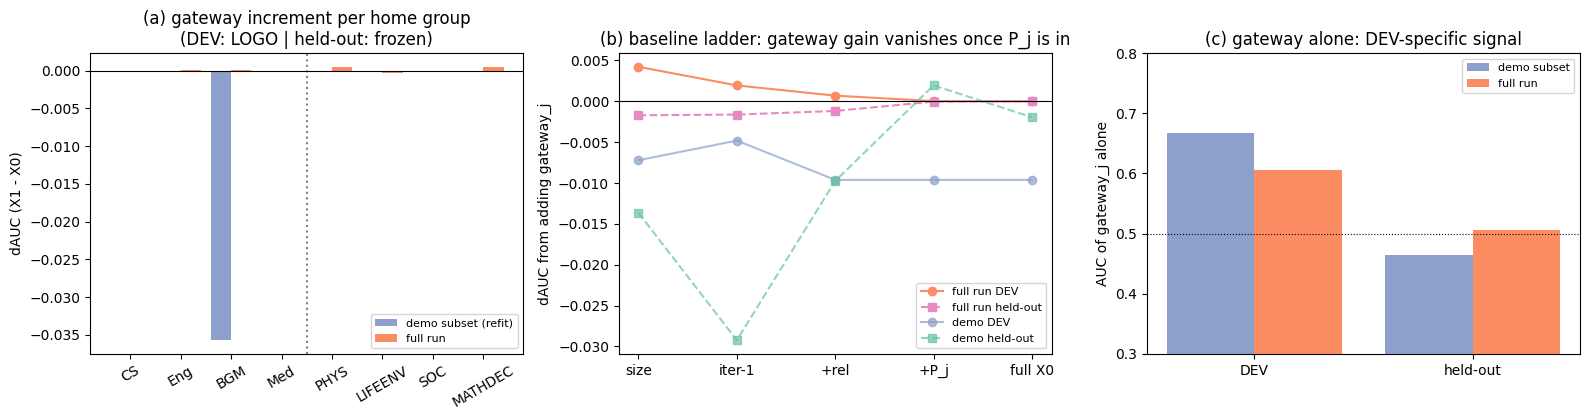

In [18]:
full = data["metadata"]["full_run_results"]
fd, fh = full["H1_dev"], full["H1_heldout"]
orig_dev = F[F.split == "DEV"]
orig_ho = F[F.split.str.startswith("HELDOUT")]
def _d(df):
    return auc(df.R, df.orig_pred_X1) - auc(df.R, df.orig_pred_X0)
fmt = lambda v: "n/a" if v is None or (isinstance(v, float) and not np.isfinite(v)) else f"{v:+.4f}"
ci = lambda c: "n/a" if not c else f"[{c[0]:+.4f}, {c[1]:+.4f}]"
table = pd.DataFrame({
    "demo (refit here)": [fmt(res["primary"]["dauc"]), ci(res["primary"]["boot_ci95"]),
                          fmt(res_ho["primary"]["dauc"]), ci(res_ho["primary"]["boot_ci95"]),
                          f"{res_ho['primary']['auc_X0']:.3f}", f"{res['gateway_alone_auc']:.3f}",
                          f"{res_ho['gateway_alone_auc']:.3f}", fmt(res_ho["rival_head_to_head"]["dauc_relatedness_pair"]),
                          res_ho["verdict_H1"]["verdict"] + " (3 of 6 criteria)"],
    "full-run preds on subset": [fmt(_d(orig_dev)), "", fmt(_d(orig_ho)), "", f"{auc(orig_ho.R, orig_ho.orig_pred_X0):.3f}",
                                 "", "", "", ""],
    "full run (all episodes)": [fmt(fd["dauc"]), ci(fd["ci95"]), fmt(fh["dauc"]), ci(fh["ci95"]), f"{fh['auc_X0']:.3f}",
                                f"{full['gateway_alone_auc']['dev']:.3f}", f"{full['gateway_alone_auc']['heldout']:.3f}",
                                fmt(fh["rival_head_to_head"]["dauc_relatedness_pair"]), fh["verdict"]["verdict"]],
}, index=["DEV LOGO dAUC", "  95% CI", "held-out dAUC", "  95% CI", "held-out AUC(X0)", "gateway-alone AUC DEV",
          "gateway-alone AUC held-out", "held-out dAUC relatedness pair", "H1 verdict"])
print(table.to_string())

print("\nH3 (full run, held-out concepts): partial Spearman with O2r_resid given B5")
h3 = full["H3_heldout"]
print(pd.DataFrame({v: {"partial_rho": h3[v]["partial_rho"], "p_perm": h3[v]["p"],
                        "holm_p": h3.get("holm", {}).get(v, math.nan)} for v in ["G", "G_A", "G_btw", "REL_home"]}).T.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
# (a) per-group dAUC
gs = DEV_GROUPS + HELD_GROUPS
demo_g = [res["primary"]["per_group"][g]["dauc"] for g in DEV_GROUPS] + \
         [res_ho["primary"]["per_group"][g]["dauc"] for g in HELD_GROUPS]
full_g = [fd["per_group"][g] for g in DEV_GROUPS] + [fh["per_group"][g] for g in HELD_GROUPS]
x = np.arange(len(gs))
axes[0].bar(x - 0.2, np.nan_to_num(demo_g), 0.4, label="demo subset (refit)", color="#8da0cb")
axes[0].bar(x + 0.2, full_g, 0.4, label="full run", color="#fc8d62")
axes[0].axvline(3.5, color="grey", ls=":")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_xticks(x, gs, rotation=30)
axes[0].set_ylabel("dAUC (X1 - X0)")
axes[0].set_title("(a) gateway increment per home group\n(DEV: LOGO | held-out: frozen)")
axes[0].legend(fontsize=8)
# (b) ladder
names = ["L0_size_only", "L1_iter1_base", "L2_plus_relatedness", "L3_plus_Pj", "L4_full_X0"]
xl = np.arange(len(names))
axes[1].plot(xl, [full["ladder_dev"][n] for n in names], "o-", color="#fc8d62", label="full run DEV")
axes[1].plot(xl, [full["ladder_heldout"][n] for n in names], "s--", color="#e78ac3", label="full run held-out")
axes[1].plot(xl, [res["ladder"][n]["dauc"] for n in names], "o-", color="#8da0cb", alpha=0.7, label="demo DEV")
axes[1].plot(xl, [res_ho["ladder"][n]["dauc"] for n in names], "s--", color="#66c2a5", alpha=0.7, label="demo held-out")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xticks(xl, ["size", "iter-1", "+rel", "+P_j", "full X0"])
axes[1].set_ylabel("dAUC from adding gateway_j")
axes[1].set_title("(b) baseline ladder: gateway gain vanishes once P_j is in")
axes[1].legend(fontsize=8)
# (c) gateway alone
lab = ["DEV", "held-out"]
axes[2].bar(np.arange(2) - 0.2, [res["gateway_alone_auc"], res_ho["gateway_alone_auc"]], 0.4, color="#8da0cb", label="demo subset")
axes[2].bar(np.arange(2) + 0.2, [full["gateway_alone_auc"]["dev"], full["gateway_alone_auc"]["heldout"]], 0.4,
            color="#fc8d62", label="full run")
axes[2].axhline(0.5, color="k", ls=":", lw=0.8)
axes[2].set_xticks(np.arange(2), lab)
axes[2].set_ylim(0.3, 0.8)
axes[2].set_ylabel("AUC of gateway_j alone")
axes[2].set_title("(c) gateway alone: DEV-specific signal")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()